In [22]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1(a):
p_infected = 0.02
n_soldiers = 10
p_positive = 1 - (1 - p_infected) ** n_soldiers
print(f"(1a) Probability that the mixed blood test is positive: {p_positive:.4f}")

# 1(b):
p_john_given_positive = p_infected / p_positive
print(f"(1b) Probability that John is infected given a positive test: {p_john_given_positive:.4f}")

# 1(c):
expected_tests = 1 + n_soldiers * p_positive
print(f"(1c) Expected total number of tests: {expected_tests:.2f}")



(1a) Probability that the mixed blood test is positive: 0.1829
(1b) Probability that John is infected given a positive test: 0.1093
(1c) Expected total number of tests: 2.83


In [24]:
# Problem 2: 

file_path = r"C:\Users\dunca\OneDrive\Desktop\STAT 603\HW10\callcenterdata.txt"
with open(file_path) as file:
    content = file.read().replace("\n",",")
    data_list = content.split(",")
    cleaned_data = [int(x) for x in data_list if x.strip().isdigit()]
    

call_data = np.array(cleaned_data)



[0.00462963 0.02546296 0.04398148 0.05092593 0.08101852 0.08333333
 0.08333333 0.1087963  0.08564815 0.10416667 0.09027778 0.06712963
 0.04861111 0.03703704 0.03009259 0.02314815 0.01388889 0.00925926
 0.00462963 0.00231481 0.00231481]
(2b) Average number of calls per 10 minutes: 7.9213


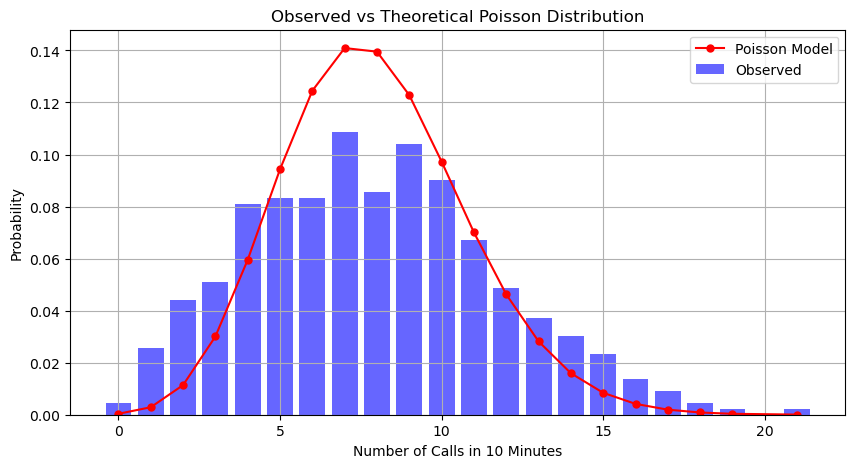

In [28]:
# (2a)
unique_counts, count_frequencies = np.unique(call_data, return_counts=True)
observed_probabilities = count_frequencies / sum(count_frequencies)
print(observed_probabilities)

# (2b)
lambda_hat = np.mean(call_data)
print(f"(2b) Average number of calls per 10 minutes: {lambda_hat:.4f}")

# (2c)
poisson_probabilities = stats.poisson.pmf(unique_counts, lambda_hat)

# (2d)
plt.figure(figsize=(10, 5))
plt.bar(unique_counts, observed_probabilities, alpha=0.6, label='Observed', color='blue')
plt.plot(unique_counts, poisson_probabilities, 'ro-', label='Poisson Model', markersize=5)
plt.xlabel('Number of Calls in 10 Minutes')
plt.ylabel('Probability')
plt.title('Observed vs Theoretical Poisson Distribution')
plt.legend()
plt.grid()
plt.show()